# Notebook 12: NeuralODE — Latent Rate Refinement

**Goal:** Understand the neural post-fit refinement workflow in `phoscrosstalk.neuralODE`.

After mechanistic fitting, learned MLP rate functions replace the mechanistic `k_act(t)` and `s_prod(t)` latent rates.

## 1. Motivation

The mechanistic `k_act_fn` and `s_prod_fn` are derived from data via interpolation and transfer functions. They may be imperfect when:

- TF or kinase data are missing (rates fall back to constants)
- The transfer function shape is misspecified
- Dynamics are stiff and the mechanistic rate is too smooth

**Neural refinement** replaces these with a small MLP `t → k̂_act(t)`, `t → ŝ_prod(t)`, trained to minimise data loss while staying close to the mechanistic prior.

## 2. Architecture

```
LatentRateMLP
  in_size  : 1 (scalar time t)
  hidden   : [width] * depth  (softplus activations)
  out_size : K
  output   : softplus → always positive

NeuralRateGenerator
  k_act_net   : LatentRateMLP  (features → k̂_act ∈ ℝ^K)
  s_prod_net  : LatentRateMLP  (features → ŝ_prod ∈ ℝ^K)
```

## 3. Two Training Modes

| Mode | What is trained | What is fixed |
|------|----------------|---------------|
| **Frozen-θ** | neural weights only | `theta_best` |
| **Joint** | neural weights + θ | — |

**Frozen-θ** is faster and safer. **Joint** allows θ to adapt.

## 4. Loss Function

$$\mathcal{L} = w_p\,\mathrm{MSE}(P_{\mathrm{sim}}, P_{\mathrm{data}}) + w_a\,\mathrm{MSE}(A_{\mathrm{sim}}, A_{\mathrm{data}})$$

$$+ \lambda_k\,\|\hat{k}_{\mathrm{act}}(t) - k_{\mathrm{act}}^{\mathrm{mech}}(t)\|^2 + \lambda_s\,\|\hat{s}_{\mathrm{prod}}(t) - s_{\mathrm{prod}}^{\mathrm{mech}}(t)\|^2$$

The prior terms (`prior_weight_k_act`, `prior_weight_s_prod`) prevent the neural rates from diverging from the mechanistic solution.

## 5. `[neural_ode]` Config Section

```toml
[neural_ode]
enabled              = false
width                = 32
depth                = 2
steps                = 500
learning_rate        = 1e-3
prior_weight_k_act   = 1.0
prior_weight_s_prod  = 1.0
use_optax            = true
optimizer            = "adabelief"
optax_loop           = "python"
```

**Neural bundle** saved in `outdir/neural_ode_bundle/`:

| File | Contents |
|---|---|
| `neural_ode_model.eqx` | Equinox model weights |
| `neural_ode_bundle_meta.json` | `K, width, depth, in_size, learn_theta, bundle_format_version` |
| `theta_refined.npy` | Refined θ (joint) or `theta_best` copy (frozen) |

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SAMPLE_DIR = PROJECT_ROOT / "notebooks" / "sample_data"
OUTPUT_DIR = PROJECT_ROOT / "notebooks" / "_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

rng = np.random.default_rng(42)
print("Setup complete.")

Setup complete.


In [2]:
from phoscrosstalk.data_loader import load_site_data, load_rna_data

TIMEPOINTS = list(range(1, 15))
sites, proteins, site_prot_idx, positions, t_phos, Y, A_data, A_proteins = \
    load_site_data(str(SAMPLE_DIR / 'protephospho.csv'), TIMEPOINTS)
K = len(proteins)
M = 2   # kinases in sample data
N = len(sites)
print(f'K={K}, M={M}, N={N}')

K=3, M=2, N=9


## 6. Instantiate NeuralRateGenerator

We create a small instance (width=8, depth=1) to inspect the forward pass. No training is performed here.

In [3]:
import jax
import jax.numpy as jnp
import numpy as np

from phoscrosstalk.neuralODE import NeuralRateGenerator

key = jax.random.PRNGKey(0)
neural_gen = NeuralRateGenerator(K=K, width=8, depth=1, key=key)
print('NeuralRateGenerator created')
print('  k_act_net  :', neural_gen.k_act_net)
print('  s_prod_net :', neural_gen.s_prod_net)

NeuralRateGenerator created
  k_act_net  : LatentRateMLP(
  mlp=MLP(
    layers=(
      Linear(
        weight=f64[8,7],
        bias=f64[8],
        in_features=7,
        out_features=8,
        use_bias=True
      ),
      Linear(
        weight=f64[0,8,8],
        bias=f64[0,8],
        in_features=8,
        out_features=8,
        use_bias=True
      ),
      Linear(
        weight=f64[3,8],
        bias=f64[3],
        in_features=8,
        out_features=3,
        use_bias=True
      )
    ),
    activation=<PjitFunction of <function softplus at 0x79a2cf3828e0>>,
    final_activation=<function LatentRateMLP.__init__.<locals>.<lambda>>,
    use_bias=True,
    use_final_bias=True,
    in_size=7,
    out_size=3,
    width_size=8,
    depth=1,
    scan=True
  ),
  out_scale=f64[3]
)
  s_prod_net : LatentRateMLP(
  mlp=MLP(
    layers=(
      Linear(
        weight=f64[8,7],
        bias=f64[8],
        in_features=7,
        out_features=8,
        use_bias=True
      ),
      Line

In [4]:
# Forward pass: features = [norm_t, k_act_init(t), s_prod_init(t)]
# For a quick demo we use a zero feature vector (K=3 → in_size=1+3+3=7)
in_size = 1 + K + K
feat_test = jnp.zeros(in_size)
k_hat, s_hat = neural_gen(feat_test)   # returns (k_hat_act, s_hat_prod)
print(f'k_hat_act  shape: {k_hat.shape}  values: {np.array(k_hat).round(4)}')
print(f's_hat_prod shape: {s_hat.shape}  values: {np.array(s_hat).round(4)}')

k_hat_act  shape: (3,)  values: [0.4856 0.4948 0.6491]
s_hat_prod shape: (3,)  values: [0.5789 0.5904 0.9704]


## 7. Plot Untrained Neural Rates Over Time

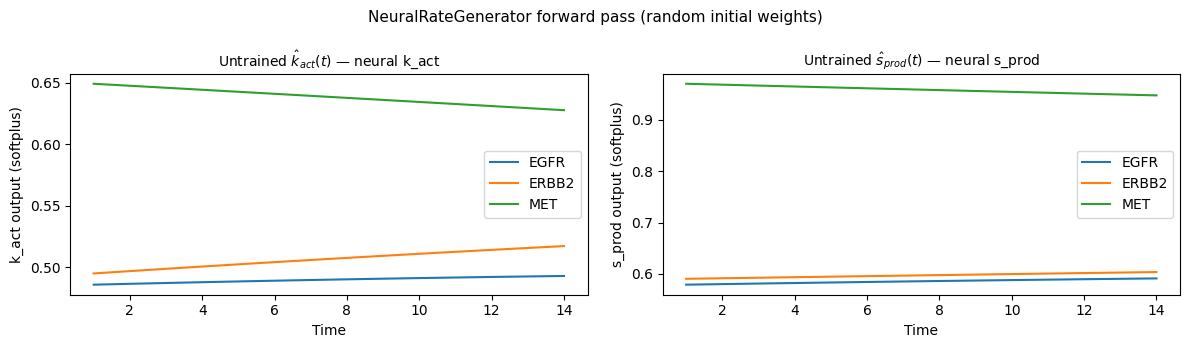

Saved: 12_neural_rates_untrained.png


In [5]:
import jax
import jax.numpy as jnp

# Sweep over a time grid and collect untrained neural rate outputs
# (features = [norm_t, zeros_for_prior_rates]; we use zero priors for this demo)
in_size = 1 + K + K   # 1 (t) + K (k_act_init) + K (s_prod_init)
t_min, t_max = float(t_phos[0]), float(t_phos[-1])
t_range = t_max - t_min if t_max > t_min else 1.0

t_grid = jnp.linspace(t_min, t_max, 80)

def _eval_rates(t_scalar):
    norm_t = (t_scalar - t_min) / t_range
    feat = jnp.concatenate([jnp.array([norm_t]), jnp.zeros(K), jnp.zeros(K)])
    k_hat, s_hat = neural_gen(feat)
    return k_hat, s_hat

k_hats, s_hats = jax.vmap(_eval_rates)(t_grid)
k_np = np.array(k_hats)   # (80, K)
s_np = np.array(s_hats)   # (80, K)
t_np = np.array(t_grid)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
for i, prot in enumerate(proteins):
    axes[0].plot(t_np, k_np[:, i], label=prot)
    axes[1].plot(t_np, s_np[:, i], label=prot)
axes[0].set_title(r'Untrained $\hat{k}_{act}(t)$ — neural k_act', fontsize=10)
axes[0].set_xlabel('Time'); axes[0].set_ylabel('k_act output (softplus)'); axes[0].legend()
axes[1].set_title(r'Untrained $\hat{s}_{prod}(t)$ — neural s_prod', fontsize=10)
axes[1].set_xlabel('Time'); axes[1].set_ylabel('s_prod output (softplus)'); axes[1].legend()
plt.suptitle('NeuralRateGenerator forward pass (random initial weights)', fontsize=11)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '12_neural_rates_untrained.png', dpi=120)
plt.show()
print('Saved: 12_neural_rates_untrained.png')


## 8. Restoring a Saved Bundle

```python
from phoscrosstalk.neuralODE import load_neural_ode_bundle

bundle = load_neural_ode_bundle(outdir / 'neural_ode_bundle')
neural_model  = bundle['neural_model']   # NeuralRateGenerator
theta_refined = bundle['theta_refined']  # np.ndarray
meta          = bundle['meta']           # dict
```

## 9. When Does Neural Refinement Help?

| Situation | Benefit |
|-----------|--------|
| Missing TF input data | Neural rates compensate for absent signal |
| Stiff dynamics | MLP learns abrupt rate changes |
| Misspecified transfer function | Neural provides flexible shape |

**When it does NOT help:** sufficient mechanistic data, or when per-kinase/site interpretability is required.

## 10. NeuralODE vs PINN Mode

| Aspect | NeuralODE (this notebook) | PINN (Notebook 13) |
|--------|--------------------------|---------------------|
| When runs | AFTER mechanistic fitting | REPLACES it |
| θ vector | Used (params kept) | Not used |
| Interpretability | Partial | Low |
| Config flag | `[neural_ode] enabled=true` | `[pinn] enabled=true` |